In [10]:
import pandas as pd
import numpy as np
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed
import time
import json
import ast

In [24]:
BASE_URL = "https://api.imdbapi.dev/"

In [3]:
response = requests.get(f"{BASE_URL}/titles")
data = response.json()
df = pd.DataFrame(data["titles"])
pagetoken = data["nextPageToken"]
df

,id,type,primaryTitle,originalTitle,primaryImage,startYear,runtimeSeconds,genres,rating,plot,endYear
0,tt12042730,movie,Project Hail Mary,Project Hail Mary,{'url': 'https://m.media-amazon.com/images/M/M...,2026,9360.0,"[Drama, Sci-Fi, Thriller]","{'aggregateRating': 8.4, 'voteCount': 127808}",A science teacher wakes up alone on a spaceshi...,NaN
1,tt32937780,tvMiniSeries,Something Very Bad Is Going to Happen,Something Very Bad Is Going to Happen,{'url': 'https://m.media-amazon.com/images/M/M...,2026,2700.0,"[Drama, Horror]","{'aggregateRating': 6.8, 'voteCount': 7294}",A certain atmosphere of horror is felt the wee...,2026.0
2,tt31938062,tvSeries,The Pitt,The Pitt,{'url': 'https://m.media-amazon.com/images/M/M...,2025,3000.0,[Drama],"{'aggregateRating': 8.9, 'voteCount': 129378}",The daily lives of healthcare professionals in...,NaN
3,tt33204276,tvSeries,The Madison,The Madison,{'url': 'https://m.media-amazon.com/images/M/M...,2026,NaN,"[Action, Drama]","{'aggregateRating': 8, 'voteCount': 9257}",A New York family's life unravels after a trag...,NaN
4,tt15574124,movie,Peaky Blinders: The Immortal Man,Peaky Blinders: The Immortal Man,{'url': 'https://m.media-amazon.com/images/M/M...,2026,6720.0,"[Crime, Drama, History]","{'aggregateRating': 6.6, 'voteCount': 54632}","During World War II, Tommy Shelby returns to a...",NaN
5,tt27552099,movie,Mike & Nick & Nick & Alice,Mike & Nick & Nick & Alice,{'url': 'https://m.media-amazon.com/images/M/M...,2026,6420.0,"[Action, Comedy, Crime]","{'aggregateRating': 6.3, 'voteCount': 6488}",Two friends navigate the dangerous world of or...,NaN
6,tt31810018,tvSeries,Detective Hole,Jo Nesbo's Detective Hole,{'url': 'https://m.media-amazon.com/images/M/M...,2026,3000.0,"[Crime, Drama, Mystery, Thriller]","{'aggregateRating': 7.9, 'voteCount': 5520}","A brilliant but troubled detective, Harry Hole...",NaN
7,tt6741278,tvSeries,Invincible,Invincible,{'url': 'https://m.media-amazon.com/images/M/M...,2021,3000.0,"[Animation, Action, Adventure, Drama, Fantasy,...","{'aggregateRating': 8.7, 'voteCount': 313951}",When 17-year-old Mark Grayson inherits superpo...,NaN
8,tt11737520,tvSeries,One Piece,One Piece,{'url': 'https://m.media-amazon.com/images/M/M...,2023,3600.0,"[Action, Adventure, Comedy, Drama, Fantasy]","{'aggregateRating': 8.3, 'voteCount': 201304}","With his straw hat and ragtag crew, young pira...",NaN
9,tt12343534,tvSeries,Jujutsu Kaisen,Jujutsu Kaisen,{'url': 'https://m.media-amazon.com/images/M/M...,2020,1440.0,"[Animation, Action, Adventure, Fantasy, Thriller]","{'aggregateRating': 8.5, 'voteCount': 200330}",After Yuji Itadori swallows a cursed talisman ...,NaN


In [43]:
response = requests.get(f"{BASE_URL}/titles")
data = response.json()
df = pd.DataFrame(data["titles"])
pagetoken = data["nextPageToken"]
print(f"Page 0: Fetched initial {len(df)} rows")
time.sleep(1)  

for page in range(1, 10):
      try:
            response = requests.get(f"{BASE_URL}/titles?types=MOVIE&pageToken={pagetoken}", timeout=10)
            
            if response.status_code == 429:
                  wait_time = int(response.headers.get("Retry-After", 5))
                  print(f"Page {page}: Rate limited! Waiting {wait_time}s...")
                  time.sleep(wait_time)
                  continue
            
            response.raise_for_status()
            
            if not response.text:
                  print(f"Page {page}: Empty response - reached end of data")
                  break
            
            data = response.json()
            
            if "titles" not in data or not data["titles"]:
                  print(f"Page {page}: No more titles - reached end of data")
                  break
                  
            df_page = pd.DataFrame(data["titles"])
            df = pd.concat([df, df_page], ignore_index=True)
            
            if "nextPageToken" in data and data["nextPageToken"]:
                  pagetoken = data["nextPageToken"]
            else:
                  print(f"Page {page}: No nextPageToken - reached end")
                  break
            
            time.sleep(1)  
      except Exception as e:
            print(f"Page {page}: Error - {type(e).__name__}: {e}")
            break

print(f"\n✓ Final shape: {df.shape}")
print(f"✓ Total rows: {len(df)}")
display(df.head())

Page 0: Fetched initial 50 rows

✓ Final shape: (500, 11)
✓ Total rows: 500


,id,type,primaryTitle,originalTitle,primaryImage,startYear,runtimeSeconds,genres,rating,plot,endYear
0,tt12042730,movie,Project Hail Mary,Project Hail Mary,{'url': 'https://m.media-amazon.com/images/M/M...,2026,9360.0,"[Drama, Sci-Fi, Thriller]","{'aggregateRating': 8.4, 'voteCount': 127808}",A science teacher wakes up alone on a spaceshi...,NaN
1,tt32937780,tvMiniSeries,Something Very Bad Is Going to Happen,Something Very Bad Is Going to Happen,{'url': 'https://m.media-amazon.com/images/M/M...,2026,2700.0,"[Drama, Horror]","{'aggregateRating': 6.8, 'voteCount': 7027}",A certain atmosphere of horror is felt the wee...,2026.0
2,tt31938062,tvSeries,The Pitt,The Pitt,{'url': 'https://m.media-amazon.com/images/M/M...,2025,3000.0,[Drama],"{'aggregateRating': 8.9, 'voteCount': 129378}",The daily lives of healthcare professionals in...,NaN
3,tt33204276,tvSeries,The Madison,The Madison,{'url': 'https://m.media-amazon.com/images/M/M...,2026,NaN,"[Action, Drama]","{'aggregateRating': 8, 'voteCount': 9257}",A New York family's life unravels after a trag...,NaN
4,tt15574124,movie,Peaky Blinders: The Immortal Man,Peaky Blinders: The Immortal Man,{'url': 'https://m.media-amazon.com/images/M/M...,2026,6720.0,"[Crime, Drama, History]","{'aggregateRating': 6.6, 'voteCount': 54632}","During World War II, Tommy Shelby returns to a...",NaN


In [57]:
df = pd.read_csv("data/box_office_data_n1000.csv")  # or however you load it

In [44]:
def fetch_box_office(ind, row, base_url, delay=0.5):
    title_id = row["id"]
    time.sleep(delay)  
    try:
        response = requests.get(f"{base_url}/titles/{title_id}/boxOffice", timeout=5)
        
        if response.status_code == 429:
            wait_time = int(response.headers.get("Retry-After", 10))
            print(f"Rate limited on {title_id}, waiting {wait_time}s...")
            time.sleep(wait_time)
            return fetch_box_office(ind, row, base_url, delay=2)  #
        
        response.raise_for_status() 
        data = response.json()
        worldwide_gross = data["worldwideGross"]["amount"] if "worldwideGross" in data else None
        production_budget = data["productionBudget"]["amount"] if "productionBudget" in data else None
        return ind, worldwide_gross, production_budget, None
    except requests.Timeout:
        return ind, None, None, f"{title_id}: Timeout"
    except requests.HTTPError as e:
        return ind, None, None, f"{title_id}: HTTP {response.status_code}"
    except json.JSONDecodeError:
        return ind, None, None, f"{title_id}: Invalid JSON response"
    except Exception as e:
        return ind, None, None, f"{title_id}: {type(e).__name__}"

skipped_count = 0
for ind, row in df.iterrows():
    ind_result, worldwide_gross, production_budget, error = fetch_box_office(ind, row, BASE_URL)
    if error:
        skipped_count += 1
    else:
        df.at[ind, "worldwideGross"] = worldwide_gross
        df.at[ind, "productionBudget"] = production_budget
    
    if (ind + 1) % 100 == 0:
        print(f"Processed {ind + 1}/{len(df)} titles...")

print(f"\n✓ Complete! Skipped {skipped_count} titles due to errors")
print(f"✓ Box office data added to {len(df) - skipped_count} rows")

Processed 100/500 titles...
Processed 200/500 titles...
Processed 300/500 titles...
Processed 400/500 titles...
Processed 500/500 titles...

✓ Complete! Skipped 0 titles due to errors
✓ Box office data added to 500 rows


In [2]:
df = pd.read_csv("data/box_office_data_n1000.csv")  

In [3]:
df = df[(df["productionBudget"].notnull()) & (df["worldwideGross"].notnull())]

In [4]:
df

,id,type,primaryTitle,originalTitle,primaryImage,startYear,runtimeSeconds,genres,rating,plot,endYear,worldwideGross,productionBudget
0,tt12042730,movie,Project Hail Mary,Project Hail Mary,{'url': 'https://m.media-amazon.com/images/M/M...,2026.0,9360.0,"['Drama', 'Sci-Fi', 'Thriller']","{'aggregateRating': 8.4, 'voteCount': 129068}",A science teacher wakes up alone on a spaceshi...,NaN,300802240.0,200000000.0
12,tt8036976,movie,Send Help,Send Help,{'url': 'https://m.media-amazon.com/images/M/M...,2026.0,6780.0,"['Adventure', 'Horror', 'Thriller']","{'aggregateRating': 6.9, 'voteCount': 57393}",When an employee and her insufferable boss bec...,NaN,94004231.0,40000000.0
16,tt30144839,movie,One Battle After Another,One Battle After Another,{'url': 'https://m.media-amazon.com/images/M/M...,2025.0,9660.0,"['Action', 'Crime', 'Drama', 'Thriller']","{'aggregateRating': 7.7, 'voteCount': 377867}","When their enemy resurfaces after 16 years, a ...",NaN,210906028.0,130000000.0
20,tt33978029,movie,Ready or Not 2: Here I Come,Ready or Not 2: Here I Come,{'url': 'https://m.media-amazon.com/images/M/M...,2026.0,6480.0,"['Comedy', 'Horror', 'Thriller']","{'aggregateRating': 7, 'voteCount': 9410}","After surviving one deadly game, Grace and her...",NaN,24038575.0,20000000.0
21,tt33244668,movie,Anaconda,Anaconda,{'url': 'https://m.media-amazon.com/images/M/M...,2025.0,5940.0,"['Action', 'Adventure', 'Comedy']","{'aggregateRating': 5.6, 'voteCount': 45201}",A group of friends are going through a mid-lif...,NaN,134974943.0,45000000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
987,tt0102057,movie,Hook,Hook,{'url': 'https://m.media-amazon.com/images/M/M...,1991.0,8520.0,"['Adventure', 'Comedy', 'Family', 'Fantasy']","{'aggregateRating': 6.8, 'voteCount': 290602}","When Captain James Hook kidnaps his children, ...",NaN,300854823.0,70000000.0
991,tt8115900,movie,The Bad Guys,The Bad Guys,{'url': 'https://m.media-amazon.com/images/M/M...,2022.0,6000.0,"['Animation', 'Adventure', 'Comedy', 'Crime', ...","{'aggregateRating': 6.9, 'voteCount': 79303}","To avoid prison, a gang of notorious animal cr...",NaN,250387888.0,70000000.0
992,tt0089218,movie,The Goonies,The Goonies,{'url': 'https://m.media-amazon.com/images/M/M...,1985.0,6840.0,"['Adventure', 'Comedy', 'Family']","{'aggregateRating': 7.7, 'voteCount': 325511}",A group of young misfits called The Goonies di...,NaN,65642529.0,19000000.0
997,tt2084970,movie,The Imitation Game,The Imitation Game,{'url': 'https://m.media-amazon.com/images/M/M...,2014.0,6840.0,"['Biography', 'Drama', 'Thriller', 'War']","{'aggregateRating': 8, 'voteCount': 875353}","During World War II, the English mathematical ...",NaN,233555708.0,14000000.0


In [7]:
def check_starmeter(base_url=BASE_URL, max_pages=100, delay=1.0):
      response = requests.get(f"{base_url}/chart/starmeter", timeout=10)
      response.raise_for_status()
      data = response.json()
      items = []
      names = data.get("names", [])
      nextPageToken = data.get("nextPageToken")
      items.extend([{**name, "page": 0} for name in names])
      
      for page in range(1, max_pages):
            if not nextPageToken:
                  break
            print(f"Checking starmeter page {page}...")
            response = requests.get(f"{base_url}/chart/starmeter?pageToken={nextPageToken}", timeout=10)
            if response.status_code == 429:
                  wait_time = int(response.headers.get("Retry-After", 5))
                  print(f"Rate limited on starmeter page {page}, waiting {wait_time}s...")
                  time.sleep(wait_time)
                  continue
            
            response.raise_for_status()
            data = response.json()
            names = data.get("names", [])
            nextPageToken = data.get("nextPageToken")
            if not names:
                  print(f"No names found on starmeter page {page}, stopping.")
                  break
            items.extend([{**name, "page": page} for name in names])
            time.sleep(delay)
      
      return pd.DataFrame(items)

starmeter_df = check_starmeter()
starmeter_df.head()

Checking starmeter page 1...
Checking starmeter page 2...
Checking starmeter page 3...
Checking starmeter page 4...
Checking starmeter page 5...
Checking starmeter page 6...
Checking starmeter page 7...
Checking starmeter page 8...
Checking starmeter page 9...
Checking starmeter page 10...
Checking starmeter page 11...
Checking starmeter page 12...
Checking starmeter page 13...
Checking starmeter page 14...
Checking starmeter page 15...
Checking starmeter page 16...
Checking starmeter page 17...
Checking starmeter page 18...
Checking starmeter page 19...
Checking starmeter page 20...
Checking starmeter page 21...
Checking starmeter page 22...
Checking starmeter page 23...
Checking starmeter page 24...
Checking starmeter page 25...
Checking starmeter page 26...
Checking starmeter page 27...
Checking starmeter page 28...
Checking starmeter page 29...
Checking starmeter page 30...
Checking starmeter page 31...
Checking starmeter page 32...
Checking starmeter page 33...
Checking starmeter 

,id,displayName,primaryImage,heightCm,birthDate,deathDate,meterRanking,page
0,nm0281619,Carrie Anne Fleming,{'url': 'https://m.media-amazon.com/images/M/M...,170.0,"{'year': 1974, 'month': 8, 'day': 16}","{'year': 2026, 'month': 2, 'day': 26}","{'currentRank': 1, 'changeDirection': 'UP', 'd...",0
1,nm0331516,Ryan Gosling,{'url': 'https://m.media-amazon.com/images/M/M...,184.0,"{'year': 1980, 'month': 11, 'day': 12}",NaN,"{'currentRank': 2, 'changeDirection': 'UP', 'd...",0
2,nm1683768,Beau Garrett,{'url': 'https://m.media-amazon.com/images/M/M...,178.0,"{'year': 1982, 'month': 12, 'day': 28}",NaN,"{'currentRank': 3, 'changeDirection': 'UP', 'd...",0
3,nm1197689,Sandra Hüller,{'url': 'https://m.media-amazon.com/images/M/M...,173.0,"{'year': 1978, 'month': 4, 'day': 30}",NaN,"{'currentRank': 4, 'changeDirection': 'UP', 'd...",0
4,nm4422686,Barry Keoghan,{'url': 'https://m.media-amazon.com/images/M/M...,173.0,"{'year': 1992, 'month': 10, 'day': 18}",NaN,"{'currentRank': 5, 'changeDirection': 'UP', 'd...",0


In [58]:
star_df.to_csv("data/starmeter_top.csv", index=False)

In [59]:
star_df = pd.read_csv("data/starmeter_top.csv")
star_df

,id,displayName,primaryImage,heightCm,birthDate,deathDate,meterRanking,page,currentRank,currentRank_Tier
0,nm0281619,Carrie Anne Fleming,{'url': 'https://m.media-amazon.com/images/M/M...,170.0,"{'year': 1974, 'month': 8, 'day': 16}","{'year': 2026, 'month': 2, 'day': 26}","{'currentRank': 1, 'changeDirection': 'UP', 'd...",0,1.0,9.0
1,nm0331516,Ryan Gosling,{'url': 'https://m.media-amazon.com/images/M/M...,184.0,"{'year': 1980, 'month': 11, 'day': 12}",NaN,"{'currentRank': 2, 'changeDirection': 'UP', 'd...",0,2.0,9.0
2,nm1683768,Beau Garrett,{'url': 'https://m.media-amazon.com/images/M/M...,178.0,"{'year': 1982, 'month': 12, 'day': 28}",NaN,"{'currentRank': 3, 'changeDirection': 'UP', 'd...",0,3.0,9.0
3,nm1197689,Sandra Hüller,{'url': 'https://m.media-amazon.com/images/M/M...,173.0,"{'year': 1978, 'month': 4, 'day': 30}",NaN,"{'currentRank': 4, 'changeDirection': 'UP', 'd...",0,4.0,9.0
4,nm4422686,Barry Keoghan,{'url': 'https://m.media-amazon.com/images/M/M...,173.0,"{'year': 1992, 'month': 10, 'day': 18}",NaN,"{'currentRank': 5, 'changeDirection': 'UP', 'd...",0,5.0,9.0
...,...,...,...,...,...,...,...,...,...,...
9995,nm0930570,Evan Williams,{'url': 'https://m.media-amazon.com/images/M/M...,178.0,"{'year': 1985, 'month': 3, 'day': 11}",NaN,NaN,99,NaN,NaN
9996,nm2965271,Arthur Darvill,{'url': 'https://m.media-amazon.com/images/M/M...,180.0,"{'year': 1982, 'month': 6, 'day': 17}",NaN,NaN,99,NaN,NaN
9997,nm7669972,Maria Chiara Giannetta,{'url': 'https://m.media-amazon.com/images/M/M...,163.0,"{'year': 1992, 'month': 5, 'day': 20}",NaN,NaN,99,NaN,NaN
9998,nm0005254,Tahj Mowry,{'url': 'https://m.media-amazon.com/images/M/M...,170.0,"{'year': 1986, 'month': 5, 'day': 17}",NaN,NaN,99,NaN,NaN


In [11]:
star_df["currentRank"] = star_df["meterRanking"].apply(
    lambda x: ast.literal_eval(x).get("currentRank") if isinstance(x, str) else (x.get("currentRank") if isinstance(x, dict) else None)
)
star_df

,id,displayName,primaryImage,heightCm,birthDate,deathDate,meterRanking,page,currentRank
0,nm0281619,Carrie Anne Fleming,{'url': 'https://m.media-amazon.com/images/M/M...,170.0,"{'year': 1974, 'month': 8, 'day': 16}","{'year': 2026, 'month': 2, 'day': 26}","{'currentRank': 1, 'changeDirection': 'UP', 'd...",0,1.0
1,nm0331516,Ryan Gosling,{'url': 'https://m.media-amazon.com/images/M/M...,184.0,"{'year': 1980, 'month': 11, 'day': 12}",NaN,"{'currentRank': 2, 'changeDirection': 'UP', 'd...",0,2.0
2,nm1683768,Beau Garrett,{'url': 'https://m.media-amazon.com/images/M/M...,178.0,"{'year': 1982, 'month': 12, 'day': 28}",NaN,"{'currentRank': 3, 'changeDirection': 'UP', 'd...",0,3.0
3,nm1197689,Sandra Hüller,{'url': 'https://m.media-amazon.com/images/M/M...,173.0,"{'year': 1978, 'month': 4, 'day': 30}",NaN,"{'currentRank': 4, 'changeDirection': 'UP', 'd...",0,4.0
4,nm4422686,Barry Keoghan,{'url': 'https://m.media-amazon.com/images/M/M...,173.0,"{'year': 1992, 'month': 10, 'day': 18}",NaN,"{'currentRank': 5, 'changeDirection': 'UP', 'd...",0,5.0
...,...,...,...,...,...,...,...,...,...
9995,nm0930570,Evan Williams,{'url': 'https://m.media-amazon.com/images/M/M...,178.0,"{'year': 1985, 'month': 3, 'day': 11}",NaN,NaN,99,NaN
9996,nm2965271,Arthur Darvill,{'url': 'https://m.media-amazon.com/images/M/M...,180.0,"{'year': 1982, 'month': 6, 'day': 17}",NaN,NaN,99,NaN
9997,nm7669972,Maria Chiara Giannetta,{'url': 'https://m.media-amazon.com/images/M/M...,163.0,"{'year': 1992, 'month': 5, 'day': 20}",NaN,NaN,99,NaN
9998,nm0005254,Tahj Mowry,{'url': 'https://m.media-amazon.com/images/M/M...,170.0,"{'year': 1986, 'month': 5, 'day': 17}",NaN,NaN,99,NaN


In [17]:
def get_tier(rank):
    """Map rank values to tiers 1-9, where lower rank = higher tier"""
    try:
        if isinstance(rank, (pd.Series, list, dict)):
            return None
        if pd.isna(rank):
            return None
        rank_val = float(rank)
        if rank_val < 1:
            return None  # rank of 0 is likely invalid
        if rank_val <= 100:
            return 9
        if rank_val <= 200:
            return 8
        tier = max(9 - int((rank_val - 100) // 100), 1)
        return tier
    except (TypeError, ValueError):
        return None

star_df["currentRank_Tier"] = star_df["currentRank"].apply(get_tier)

In [19]:
star_df.tail(100)

,id,displayName,primaryImage,heightCm,birthDate,deathDate,meterRanking,page,currentRank,currentRank_Tier
9900,nm0001041,Maggie Cheung,{'url': 'https://m.media-amazon.com/images/M/M...,169.0,"{'year': 1964, 'month': 9, 'day': 20}",NaN,NaN,99,NaN,NaN
9901,nm0298221,Drew Fuller,{'url': 'https://m.media-amazon.com/images/M/M...,185.0,"{'year': 1980, 'month': 5, 'day': 19}",NaN,NaN,99,NaN,NaN
9902,nm0230826,Monica Dolan,{'url': 'https://m.media-amazon.com/images/M/M...,161.0,"{'year': 1969, 'month': 3, 'day': 15}",NaN,NaN,99,NaN,NaN
9903,nm7436280,Sloan Mannino,{'url': 'https://m.media-amazon.com/images/M/M...,155.0,NaN,NaN,NaN,99,NaN,NaN
9904,nm3209606,Moon Ga-young,{'url': 'https://m.media-amazon.com/images/M/M...,169.0,"{'year': 1996, 'month': 7, 'day': 10}",NaN,NaN,99,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
9995,nm0930570,Evan Williams,{'url': 'https://m.media-amazon.com/images/M/M...,178.0,"{'year': 1985, 'month': 3, 'day': 11}",NaN,NaN,99,NaN,NaN
9996,nm2965271,Arthur Darvill,{'url': 'https://m.media-amazon.com/images/M/M...,180.0,"{'year': 1982, 'month': 6, 'day': 17}",NaN,NaN,99,NaN,NaN
9997,nm7669972,Maria Chiara Giannetta,{'url': 'https://m.media-amazon.com/images/M/M...,163.0,"{'year': 1992, 'month': 5, 'day': 20}",NaN,NaN,99,NaN,NaN
9998,nm0005254,Tahj Mowry,{'url': 'https://m.media-amazon.com/images/M/M...,170.0,"{'year': 1986, 'month': 5, 'day': 17}",NaN,NaN,99,NaN,NaN


In [20]:
star_df[star_df["meterRanking"].isna()]

,id,displayName,primaryImage,heightCm,birthDate,deathDate,meterRanking,page,currentRank,currentRank_Tier
4993,nm0518085,Kristanna Loken,{'url': 'https://m.media-amazon.com/images/M/M...,180.0,NaN,NaN,NaN,49,NaN,NaN
4994,nm0101991,Philippa Boyens,{'url': 'https://m.media-amazon.com/images/M/M...,NaN,NaN,NaN,NaN,49,NaN,NaN
4995,nm6373769,Jess Gabor,{'url': 'https://m.media-amazon.com/images/M/M...,170.0,"{'year': 1996, 'month': 10, 'day': 23}",NaN,NaN,49,NaN,NaN
4996,nm0001704,Vincent Schiavelli,{'url': 'https://m.media-amazon.com/images/M/M...,194.0,"{'year': 1948, 'month': 11, 'day': 11}","{'year': 2005, 'month': 12, 'day': 26}",NaN,49,NaN,NaN
4997,nm0776584,Paul Schulze,{'url': 'https://m.media-amazon.com/images/M/M...,175.0,"{'year': 1962, 'month': 6, 'day': 12}",NaN,NaN,49,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
9995,nm0930570,Evan Williams,{'url': 'https://m.media-amazon.com/images/M/M...,178.0,"{'year': 1985, 'month': 3, 'day': 11}",NaN,NaN,99,NaN,NaN
9996,nm2965271,Arthur Darvill,{'url': 'https://m.media-amazon.com/images/M/M...,180.0,"{'year': 1982, 'month': 6, 'day': 17}",NaN,NaN,99,NaN,NaN
9997,nm7669972,Maria Chiara Giannetta,{'url': 'https://m.media-amazon.com/images/M/M...,163.0,"{'year': 1992, 'month': 5, 'day': 20}",NaN,NaN,99,NaN,NaN
9998,nm0005254,Tahj Mowry,{'url': 'https://m.media-amazon.com/images/M/M...,170.0,"{'year': 1986, 'month': 5, 'day': 17}",NaN,NaN,99,NaN,NaN


In [22]:
df

,id,type,primaryTitle,originalTitle,primaryImage,startYear,runtimeSeconds,genres,rating,plot,endYear,worldwideGross,productionBudget,totalStarMeter
0,tt12042730,movie,Project Hail Mary,Project Hail Mary,{'url': 'https://m.media-amazon.com/images/M/M...,2026.0,9360.0,"['Drama', 'Sci-Fi', 'Thriller']","{'aggregateRating': 8.4, 'voteCount': 129068}",A science teacher wakes up alone on a spaceshi...,NaN,300802240.0,200000000.0,0
12,tt8036976,movie,Send Help,Send Help,{'url': 'https://m.media-amazon.com/images/M/M...,2026.0,6780.0,"['Adventure', 'Horror', 'Thriller']","{'aggregateRating': 6.9, 'voteCount': 57393}",When an employee and her insufferable boss bec...,NaN,94004231.0,40000000.0,0
16,tt30144839,movie,One Battle After Another,One Battle After Another,{'url': 'https://m.media-amazon.com/images/M/M...,2025.0,9660.0,"['Action', 'Crime', 'Drama', 'Thriller']","{'aggregateRating': 7.7, 'voteCount': 377867}","When their enemy resurfaces after 16 years, a ...",NaN,210906028.0,130000000.0,0
20,tt33978029,movie,Ready or Not 2: Here I Come,Ready or Not 2: Here I Come,{'url': 'https://m.media-amazon.com/images/M/M...,2026.0,6480.0,"['Comedy', 'Horror', 'Thriller']","{'aggregateRating': 7, 'voteCount': 9410}","After surviving one deadly game, Grace and her...",NaN,24038575.0,20000000.0,0
21,tt33244668,movie,Anaconda,Anaconda,{'url': 'https://m.media-amazon.com/images/M/M...,2025.0,5940.0,"['Action', 'Adventure', 'Comedy']","{'aggregateRating': 5.6, 'voteCount': 45201}",A group of friends are going through a mid-lif...,NaN,134974943.0,45000000.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
987,tt0102057,movie,Hook,Hook,{'url': 'https://m.media-amazon.com/images/M/M...,1991.0,8520.0,"['Adventure', 'Comedy', 'Family', 'Fantasy']","{'aggregateRating': 6.8, 'voteCount': 290602}","When Captain James Hook kidnaps his children, ...",NaN,300854823.0,70000000.0,0
991,tt8115900,movie,The Bad Guys,The Bad Guys,{'url': 'https://m.media-amazon.com/images/M/M...,2022.0,6000.0,"['Animation', 'Adventure', 'Comedy', 'Crime', ...","{'aggregateRating': 6.9, 'voteCount': 79303}","To avoid prison, a gang of notorious animal cr...",NaN,250387888.0,70000000.0,0
992,tt0089218,movie,The Goonies,The Goonies,{'url': 'https://m.media-amazon.com/images/M/M...,1985.0,6840.0,"['Adventure', 'Comedy', 'Family']","{'aggregateRating': 7.7, 'voteCount': 325511}",A group of young misfits called The Goonies di...,NaN,65642529.0,19000000.0,0
997,tt2084970,movie,The Imitation Game,The Imitation Game,{'url': 'https://m.media-amazon.com/images/M/M...,2014.0,6840.0,"['Biography', 'Drama', 'Thriller', 'War']","{'aggregateRating': 8, 'voteCount': 875353}","During World War II, the English mathematical ...",NaN,233555708.0,14000000.0,0


In [26]:
BASE_URL

'https://api.imdbapi.dev/'

In [60]:
import time

df["totalStarMeter"] = 0

for ind, row in df.iterrows():
    retries = 3
    while retries > 0:
        try:
            response = requests.get(f"{BASE_URL}/titles/{row['id']}")
            
            if response.status_code == 429:
                print(f"Row {ind}: Rate limited, waiting 10s...")
                time.sleep(10)
                retries -= 1
                continue
            
            if response.status_code != 200 or not response.text.strip():
                print(f"Row {ind}: Bad response {response.status_code}")
                break

            data = response.json()
            stars = data.get("stars", [])

            if not isinstance(stars, list):
                break
            
            total = 0
            for star in stars:
                star_id = star["id"]
                match = star_df[star_df["id"] == star_id]
                if not match.empty:
                    tier = match.iloc[0]["currentRank_Tier"]
                    total += int(tier) if pd.notna(tier) else 0
            
            df.at[ind, "totalStarMeter"] = total
            time.sleep(0.5)  # ✅ polite delay between every request
            break  # success, exit retry loop

        except Exception as e:
            print(f"Row {ind}: {type(e).__name__}: {e}")
            break
    else:
        print(f"Row {ind}: Skipped after 3 retries")

print("Complete")
df[["id", "totalStarMeter"]].head(10)

Complete


,id,totalStarMeter
0,tt12042730,36
1,tt28650488,43
2,tt32430579,26
3,tt27543632,26
4,tt33244668,31
5,tt0049833,3
6,tt8036976,19
7,tt1757678,14
8,tt30144839,33
9,tt31050594,32


In [61]:
df

,id,type,primaryTitle,originalTitle,primaryImage,startYear,runtimeSeconds,genres,rating,plot,worldwideGross,productionBudget,totalStarMeter
0,tt12042730,movie,Project Hail Mary,Project Hail Mary,{'url': 'https://m.media-amazon.com/images/M/M...,2026.0,9360.0,"['Adventure', 'Comedy', 'Sci-Fi']","{'aggregateRating': 8.4, 'voteCount': 177774}",A science teacher wakes up alone on a spaceshi...,433030505,200000000,36
1,tt28650488,movie,The Super Mario Galaxy Movie,The Super Mario Galaxy Movie,{'url': 'https://m.media-amazon.com/images/M/M...,2026.0,5880.0,"['Animation', 'Adventure', 'Comedy', 'Family',...","{'aggregateRating': 6.5, 'voteCount': 25339}","Mario ventures into space, exploring cosmic wo...",437751829,110000000,43
2,tt32430579,movie,Crime 101,Crime 101,{'url': 'https://m.media-amazon.com/images/M/M...,2026.0,8400.0,"['Crime', 'Drama', 'Thriller']","{'aggregateRating': 6.8, 'voteCount': 48040}","An elusive thief, eyeing his final score, enco...",72559167,90000000,26
3,tt27543632,movie,The Housemaid,The Housemaid,{'url': 'https://m.media-amazon.com/images/M/M...,2025.0,7860.0,"['Drama', 'Mystery', 'Thriller']","{'aggregateRating': 6.8, 'voteCount': 128732}",A struggling young woman is relieved by the ch...,399318859,35000000,26
4,tt33244668,movie,Anaconda,Anaconda,{'url': 'https://m.media-amazon.com/images/M/M...,2025.0,5940.0,"['Action', 'Adventure', 'Comedy']","{'aggregateRating': 5.6, 'voteCount': 52350}",A group of friends are going through a mid-lif...,134974943,45000000,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...
737,tt0119081,movie,Event Horizon,Event Horizon,{'url': 'https://m.media-amazon.com/images/M/M...,1997.0,5760.0,"['Horror', 'Sci-Fi', 'Thriller']","{'aggregateRating': 6.6, 'voteCount': 214318}",A rescue crew is tasked with investigating the...,26677592,60000000,9
738,tt0374900,movie,Napoleon Dynamite,Napoleon Dynamite,{'url': 'https://m.media-amazon.com/images/M/M...,2004.0,5760.0,['Comedy'],"{'aggregateRating': 7, 'voteCount': 255414}",A listless and alienated teenager helps his ne...,46141106,400000,2
739,tt0095765,movie,Cinema Paradiso,Nuovo Cinema Paradiso,{'url': 'https://m.media-amazon.com/images/M/M...,1988.0,10440.0,"['Drama', 'Romance']","{'aggregateRating': 8.5, 'voteCount': 316658}","Salvatore, a famous film director, returns to ...",13502484,5000000,0
740,tt1226837,movie,Beautiful Boy,Beautiful Boy,{'url': 'https://m.media-amazon.com/images/M/M...,2018.0,7200.0,"['Biography', 'Drama']","{'aggregateRating': 7.4, 'voteCount': 127712}",A family coping with addiction over many years...,31749905,25000000,10


In [62]:
def missing_summary(df):
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(2)
    
    summary = pd.DataFrame({
        "missing_count": missing,
        "missing_pct": pct
    })
    
    return summary[summary["missing_count"] > 0].sort_values("missing_pct", ascending=False)

missing_summary(df)

,missing_count,missing_pct


In [66]:
df.to_csv("data/box_office_with_starmeter.csv", index=False)

In [63]:
df["gross_to_budget_ratio"] = df["worldwideGross"] / df["productionBudget"]

In [64]:
df

,id,type,primaryTitle,originalTitle,primaryImage,startYear,runtimeSeconds,genres,rating,plot,worldwideGross,productionBudget,totalStarMeter,gross_to_budget_ratio
0,tt12042730,movie,Project Hail Mary,Project Hail Mary,{'url': 'https://m.media-amazon.com/images/M/M...,2026.0,9360.0,"['Adventure', 'Comedy', 'Sci-Fi']","{'aggregateRating': 8.4, 'voteCount': 177774}",A science teacher wakes up alone on a spaceshi...,433030505,200000000,36,2.165153
1,tt28650488,movie,The Super Mario Galaxy Movie,The Super Mario Galaxy Movie,{'url': 'https://m.media-amazon.com/images/M/M...,2026.0,5880.0,"['Animation', 'Adventure', 'Comedy', 'Family',...","{'aggregateRating': 6.5, 'voteCount': 25339}","Mario ventures into space, exploring cosmic wo...",437751829,110000000,43,3.979562
2,tt32430579,movie,Crime 101,Crime 101,{'url': 'https://m.media-amazon.com/images/M/M...,2026.0,8400.0,"['Crime', 'Drama', 'Thriller']","{'aggregateRating': 6.8, 'voteCount': 48040}","An elusive thief, eyeing his final score, enco...",72559167,90000000,26,0.806213
3,tt27543632,movie,The Housemaid,The Housemaid,{'url': 'https://m.media-amazon.com/images/M/M...,2025.0,7860.0,"['Drama', 'Mystery', 'Thriller']","{'aggregateRating': 6.8, 'voteCount': 128732}",A struggling young woman is relieved by the ch...,399318859,35000000,26,11.409110
4,tt33244668,movie,Anaconda,Anaconda,{'url': 'https://m.media-amazon.com/images/M/M...,2025.0,5940.0,"['Action', 'Adventure', 'Comedy']","{'aggregateRating': 5.6, 'voteCount': 52350}",A group of friends are going through a mid-lif...,134974943,45000000,31,2.999443
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
737,tt0119081,movie,Event Horizon,Event Horizon,{'url': 'https://m.media-amazon.com/images/M/M...,1997.0,5760.0,"['Horror', 'Sci-Fi', 'Thriller']","{'aggregateRating': 6.6, 'voteCount': 214318}",A rescue crew is tasked with investigating the...,26677592,60000000,9,0.444627
738,tt0374900,movie,Napoleon Dynamite,Napoleon Dynamite,{'url': 'https://m.media-amazon.com/images/M/M...,2004.0,5760.0,['Comedy'],"{'aggregateRating': 7, 'voteCount': 255414}",A listless and alienated teenager helps his ne...,46141106,400000,2,115.352765
739,tt0095765,movie,Cinema Paradiso,Nuovo Cinema Paradiso,{'url': 'https://m.media-amazon.com/images/M/M...,1988.0,10440.0,"['Drama', 'Romance']","{'aggregateRating': 8.5, 'voteCount': 316658}","Salvatore, a famous film director, returns to ...",13502484,5000000,0,2.700497
740,tt1226837,movie,Beautiful Boy,Beautiful Boy,{'url': 'https://m.media-amazon.com/images/M/M...,2018.0,7200.0,"['Biography', 'Drama']","{'aggregateRating': 7.4, 'voteCount': 127712}",A family coping with addiction over many years...,31749905,25000000,10,1.269996


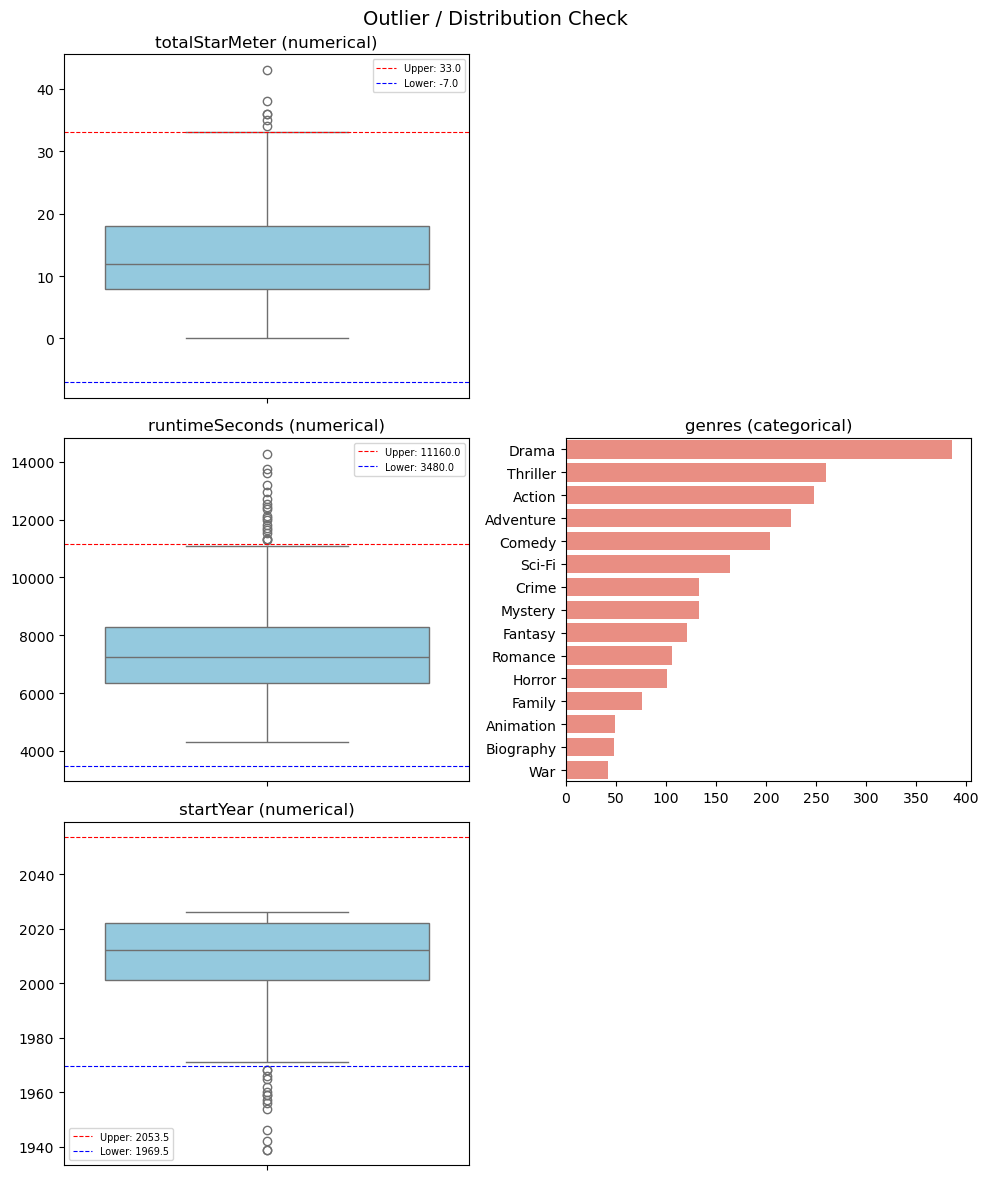

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import ast

def plot_outliers(df, columns):
    n = len(columns)
    cols = 2  # ✅ 2 columns looks cleaner
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(10, 4 * rows))
    axes = axes.flatten()

    for i, col in enumerate(columns):
        ax = axes[i]

        if col not in df.columns:
            ax.set_visible(False)
            continue

        if pd.api.types.is_numeric_dtype(df[col]):
            data = df[col].dropna()
            sns.boxplot(y=data, ax=ax, color="skyblue")

            Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
            IQR = Q3 - Q1
            lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

            ax.axhline(upper, color="red", linestyle="--", linewidth=0.8, label=f"Upper: {upper:.1f}")
            ax.axhline(lower, color="blue", linestyle="--", linewidth=0.8, label=f"Lower: {lower:.1f}")
            ax.legend(fontsize=7)
            ax.set_title(f"{col} (numerical)")

        else:
            series = df[col].dropna()

            # ✅ Handle both actual lists and stringified lists like "['Action', 'Drama']"
            def parse_entry(x):
                if isinstance(x, list):
                    return x
                if isinstance(x, str) and x.startswith("["):
                    try:
                        return ast.literal_eval(x)
                    except:
                        return [x]
                return [x]

            series = series.apply(parse_entry).explode()
            series = series.str.strip().str.strip("'\"")  # clean up any leftover quotes

            counts = series.value_counts().head(15)
            sns.barplot(x=counts.values, y=counts.index, ax=ax, color="salmon")
            ax.set_title(f"{col} (categorical)")

        ax.set_xlabel("")
        ax.set_ylabel("")

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Outlier / Distribution Check", fontsize=14)
    plt.tight_layout()
    plt.show()

plot_outliers(df, ["totalStarMeter", "aggregateRating", "runtimeSeconds", "genres", "startYear"])

In [55]:
df_sample = df.sample(100, random_state=42)

In [56]:
df_sample.to_csv("data/box_office_with_starmeter_sample.csv", index=False)

In [67]:
missing_counts = df.isna().sum()
print(missing_counts)
missing_counts[missing_counts > 0]

id                       0
type                     0
primaryTitle             0
originalTitle            0
primaryImage             0
startYear                0
runtimeSeconds           0
genres                   0
rating                   0
plot                     0
worldwideGross           0
productionBudget         0
totalStarMeter           0
gross_to_budget_ratio    0
dtype: int64


Series([], dtype: int64)

,genre_Action,genre_Adventure,genre_Animation,genre_Biography,genre_Comedy,genre_Crime,genre_Documentary,genre_Drama,genre_Family,genre_Fantasy,...,genre_Horror,genre_Music,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Sport,genre_Thriller,genre_War,genre_Western
0,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0,1,1,0,1,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,1,0,0
4,1,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


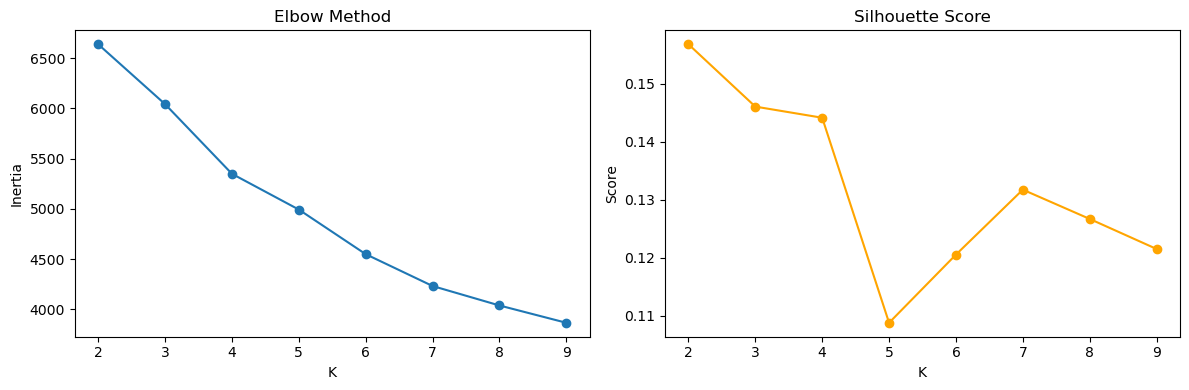

Best K by silhouette: 2


,startYear,runtimeSeconds,worldwideGross,productionBudget,totalStarMeter,gross_to_budget_ratio,aggregateRating,voteCount
cluster,,,,,,,,
0,2014.54,6956.13,1.741032e+08,8.150536e+07,13.28,4.59,6.88,257683.69
1,2001.24,8197.21,4.514497e+08,1.758209e+08,13.35,9.80,7.99,862840.30


In [71]:
import pandas as pd
import numpy as np
import ast
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# ── 1. Parse nested columns ──────────────────────────────────────────
def parse_rating(x):
    try:
        d = ast.literal_eval(x)
        return d.get("aggregateRating", np.nan), d.get("voteCount", np.nan)
    except:
        return np.nan, np.nan

def parse_genres(x):
    try:
        return ast.literal_eval(x) if isinstance(x, str) else []
    except:
        return []

df["aggregateRating"], df["voteCount"] = zip(*df["rating"].apply(parse_rating))
df["genres_parsed"] = df["genres"].apply(parse_genres)

# ── 2. Genre encoding with MultiLabelBinarizer ───────────────────────
mlb = MultiLabelBinarizer()
genre_encoded = pd.DataFrame(
    mlb.fit_transform(df["genres_parsed"]),
    columns=[f"genre_{g}" for g in mlb.classes_],
    index=df.index
)
display(genre_encoded.head())

# ── 3. Define features ───────────────────────────────────────────────
numeric_features = [
    "startYear", "runtimeSeconds", "worldwideGross",
    "productionBudget", "totalStarMeter",
    "gross_to_budget_ratio", "aggregateRating", "voteCount"
]

# Combine numeric + genre columns into one df
model_df = pd.concat([df[numeric_features], genre_encoded], axis=1).dropna()

genre_features = list(genre_encoded.columns)

# ── 4. ColumnTransformer ─────────────────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("genre", "passthrough", genre_features)  # already binary, no scaling needed
])

# ── 5. Elbow method to find optimal K ───────────────────────────────
inertias = []
silhouettes = []
K_range = range(2, 10)

X = preprocessor.fit_transform(model_df)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")

axes[1].plot(K_range, silhouettes, marker="o", color="orange")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

# ── 6. Fit final model with chosen K ────────────────────────────────
best_k = silhouettes.index(max(silhouettes)) + 2  # offset by range start
print(f"Best K by silhouette: {best_k}")

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("kmeans", KMeans(n_clusters=best_k, random_state=42, n_init=10))
])

pipeline.fit(model_df)
df.loc[model_df.index, "cluster"] = pipeline.named_steps["kmeans"].labels_
df["cluster"] = df["cluster"].astype("Int64")

# ── 7. Cluster summary ───────────────────────────────────────────────
summary = df.groupby("cluster")[numeric_features].mean().round(2)
display(summary)

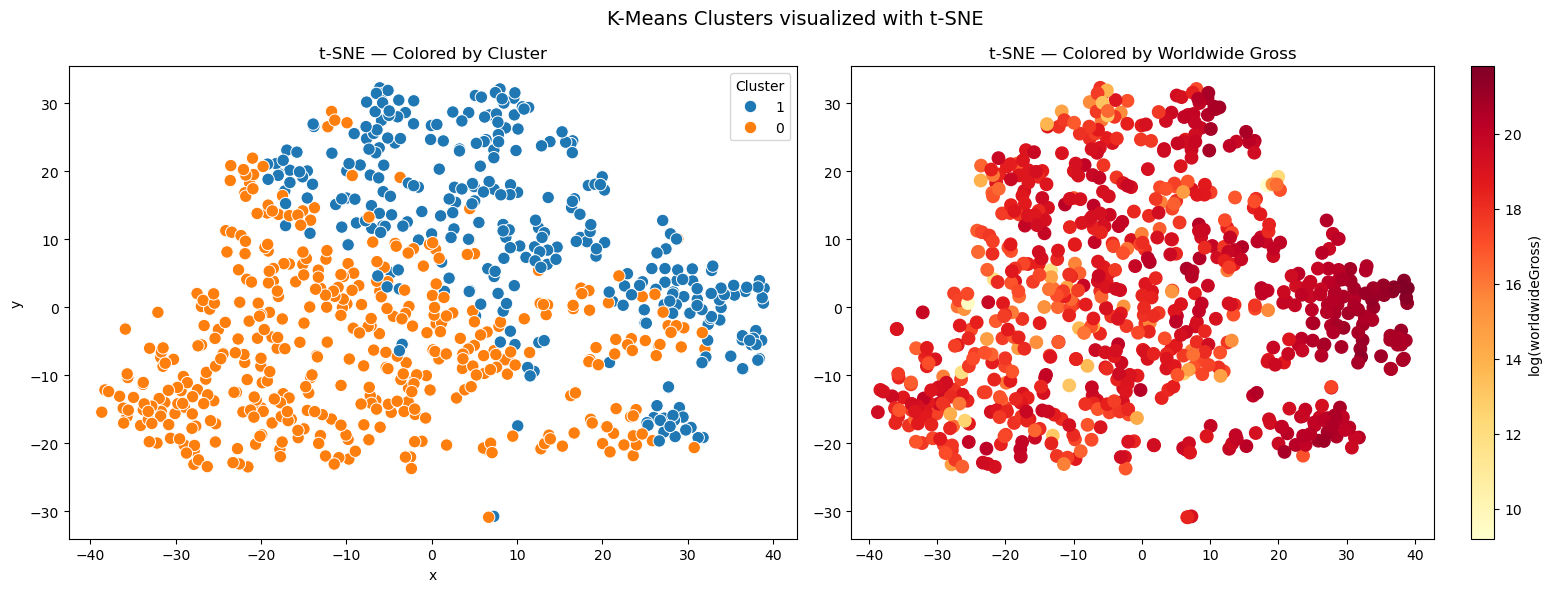

/var/folders/c5/pphx1c0n3lb12sy85_ybqxqm0000gn/T/ipykernel_7978/3628932095.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/c5/pphx1c0n3lb12sy85_ybqxqm0000gn/T/ipykernel_7978/3628932095.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/c5/pphx1c0n3lb12sy85_ybqxqm0000gn/T/ipykernel_7978/3628932095.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/c5/pphx1c0n3lb12sy85_ybqxqm0000gn/T/ipykernel_7978/3628932095.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and w

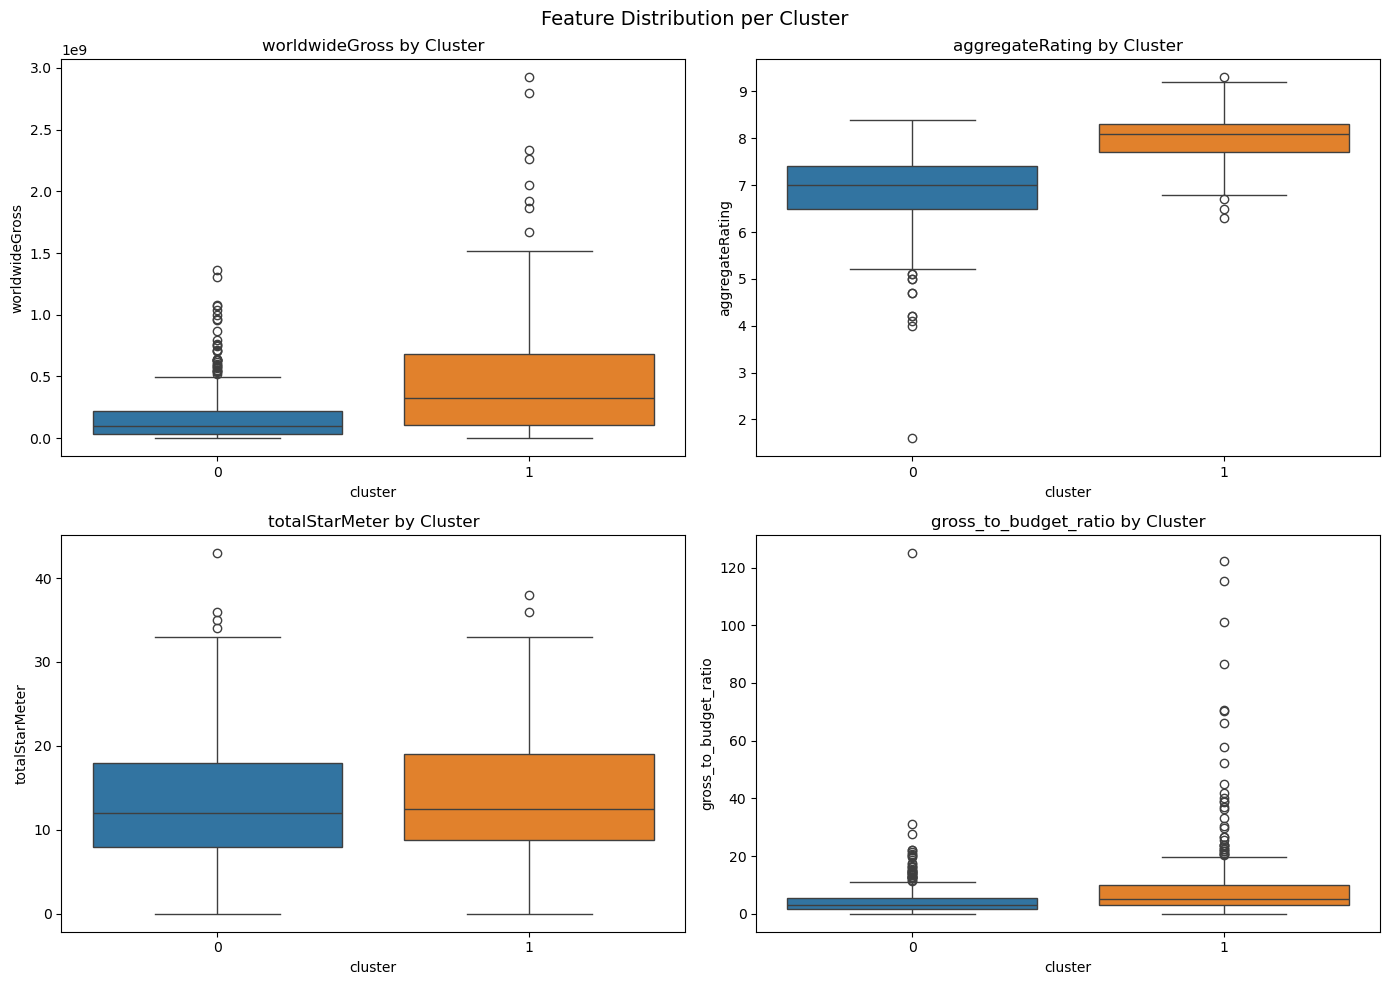

,id,primaryTitle,cluster
0,tt12042730,Project Hail Mary,1
1,tt28650488,The Super Mario Galaxy Movie,0
2,tt32430579,Crime 101,0
3,tt27543632,The Housemaid,0
4,tt33244668,Anaconda,0
5,tt0049833,The Ten Commandments,1
6,tt8036976,Send Help,0
7,tt1757678,Avatar: Fire and Ash,1
8,tt30144839,One Battle After Another,0
9,tt31050594,Mercy,0


In [74]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Get preprocessed features ────────────────────────────────────
X = pipeline.named_steps["preprocessor"].transform(model_df)
labels = pipeline.named_steps["kmeans"].labels_

# ── 2. Reduce to 2D with t-SNE ───────────────────────────────────────
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = tsne.fit_transform(X)

# ── 3. Build plot df ─────────────────────────────────────────────────
plot_df = pd.DataFrame({
    "x": X_2d[:, 0],
    "y": X_2d[:, 1],
    "cluster": labels.astype(str),
    "gross": df.loc[model_df.index, "worldwideGross"].values,
    "rating": df.loc[model_df.index, "aggregateRating"].values,
    "starMeter": df.loc[model_df.index, "totalStarMeter"].values,
})

# ── 4. t-SNE scatter plot ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=plot_df, x="x", y="y", hue="cluster",
    palette="tab10", s=80, ax=axes[0]
)
axes[0].set_title("t-SNE — Colored by Cluster")
axes[0].legend(title="Cluster")

scatter = axes[1].scatter(
    plot_df["x"], plot_df["y"],
    c=np.log1p(plot_df["gross"]),
    cmap="YlOrRd", s=80
)
plt.colorbar(scatter, ax=axes[1], label="log(worldwideGross)")
axes[1].set_title("t-SNE — Colored by Worldwide Gross")

plt.suptitle("K-Means Clusters visualized with t-SNE", fontsize=14)
plt.tight_layout()
plt.show()

# ── 5. Cluster profile boxplots ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(["worldwideGross", "aggregateRating", "totalStarMeter", "gross_to_budget_ratio"]):
    sns.boxplot(
        data=df.loc[model_df.index],
        x="cluster", y=col,
        palette="tab10", ax=axes[i]
    )
    axes[i].set_title(f"{col} by Cluster")

plt.suptitle("Feature Distribution per Cluster", fontsize=14)
plt.tight_layout()
plt.show()

# ── 6. Merge clusters back into main df ─────────────────────────────
if "cluster" in df.columns:
    df = df.drop(columns=["cluster"])

cluster_map = pd.Series(labels, index=model_df.index, name="cluster")
df = df.join(cluster_map, how="left")
df["cluster"] = df["cluster"].astype("Int64")

display(df[["id", "primaryTitle", "cluster"]].head(10))

In [ ]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings("ignore")

# ── 1. Model Registry — swap this dict to try different models ───────
MODEL_REGISTRY = {
    "gradient_boosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            "model__n_estimators": randint(100, 500),
            "model__max_depth": randint(2, 6),
            "model__learning_rate": uniform(0.01, 0.2),
            "model__subsample": uniform(0.6, 0.4),
            "model__min_samples_split": randint(2, 10),
        }
    },
    "random_forest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "model__n_estimators": randint(100, 500),
            "model__max_depth": randint(3, 10),
            "model__min_samples_split": randint(2, 10),
            "model__max_features": ["sqrt", "log2", 0.5],
        }
    },
    "ridge": {
        "model": Ridge(),
        "params": {
            "model__alpha": uniform(0.1, 100),
        }
    },
}

# ── 2. Modular Model Trainer ─────────────────────────────────────────
class MovieRegressorTrainer:
    def __init__(self, model_name, target, numeric_features, registry=MODEL_REGISTRY, n_iter=30, cv=5):
        self.model_name = model_name
        self.target = target
        self.numeric_features = numeric_features
        self.registry = registry
        self.n_iter = n_iter
        self.cv = cv
        self.best_model = None
        self.results = None

    def _build_pipeline(self, model):
        preprocessor = ColumnTransformer(transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), self.numeric_features)
        ])
        return Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

    def fit(self, df):
        data = df[self.numeric_features + [self.target]].dropna()
        X = data[self.numeric_features]
        y = data[self.target]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        config = self.registry[self.model_name]
        pipeline = self._build_pipeline(config["model"])

        search = RandomizedSearchCV(
            pipeline,
            param_distributions=config["params"],
            n_iter=self.n_iter,
            cv=self.cv,
            scoring="r2",
            random_state=42,
            n_jobs=-1,
            verbose=1
        )
        search.fit(X_train, y_train)

        self.best_model = search.best_estimator_
        y_pred = self.best_model.predict(X_test)

        self.results = {
            "model": self.model_name,
            "target": self.target,
            "best_params": search.best_params_,
            "cv_r2": round(search.best_score_, 4),
            "test_r2": round(r2_score(y_test, y_pred), 4),
            "test_mae": round(mean_absolute_error(y_test, y_pred), 4),
            "test_rmse": round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
        }
        return self

    def report(self):
        if not self.results:
            print("Model not fitted yet.")
            return
        print(f"\n{'='*50}")
        print(f"  Model     : {self.results['model']}")
        print(f"  Target    : {self.results['target']}")
        print(f"  CV R²     : {self.results['cv_r2']}")
        print(f"  Test R²   : {self.results['test_r2']}")
        print(f"  Test MAE  : {self.results['test_mae']}")
        print(f"  Test RMSE : {self.results['test_rmse']}")
        print(f"  Best Params: {self.results['best_params']}")
        print(f"{'='*50}")
        return pd.DataFrame([self.results])


# ── 3. Run & compare models ──────────────────────────────────────────
FEATURES = [
    "runtimeSeconds", "productionBudget",
    "totalStarMeter", "aggregateRating", "voteCount"
]
TARGET = "gross_to_budget_ratio"  # swap to "worldwideGross" to try another target

all_results = []
for model_name in MODEL_REGISTRY:
    trainer = MovieRegressorTrainer(
        model_name=model_name,
        target=TARGET,
        numeric_features=FEATURES,
    )
    trainer.fit(df)
    all_results.append(trainer.report())

# ── 4. Comparison table ──────────────────────────────────────────────
comparison = pd.concat(all_results, ignore_index=True)
display(comparison.sort_values("test_r2", ascending=False))

Fitting 5 folds for each of 30 candidates, totalling 150 fits



  Model     : gradient_boosting
  Target    : gross_to_budget_ratio
  CV R²     : -0.1069
  Test R²   : 0.0621
  Test MAE  : 5.6096
  Test RMSE : 14.9308
  Best Params: {'model__learning_rate': np.float64(0.0430533878126005), 'model__max_depth': 2, 'model__min_samples_split': 8, 'model__n_estimators': 108, 'model__subsample': np.float64(0.908897907718663)}
Fitting 5 folds for each of 30 candidates, totalling 150 fits

  Model     : random_forest
  Target    : gross_to_budget_ratio
  CV R²     : 0.1243
  Test R²   : 0.1821
  Test MAE  : 5.4559
  Test RMSE : 13.9431
  Best Params: {'model__max_depth': 9, 'model__max_features': 'sqrt', 'model__min_samples_split': 9, 'model__n_estimators': 228}
Fitting 5 folds for each of 30 candidates, totalling 150 fits

  Model     : ridge
  Target    : gross_to_budget_ratio
  CV R²     : -0.0603
  Test R²   : 0.0376
  Test MAE  : 5.7547
  Test RMSE : 15.1244
  Best Params: {'model__alpha': np.float64(97.09098521619943)}


,model,target,best_params,cv_r2,test_r2,test_mae,test_rmse
1,random_forest,gross_to_budget_ratio,"{'model__max_depth': 9, 'model__max_features':...",0.1243,0.1821,5.4559,13.9431
0,gradient_boosting,gross_to_budget_ratio,"{'model__learning_rate': 0.0430533878126005, '...",-0.1069,0.0621,5.6096,14.9308
2,ridge,gross_to_budget_ratio,{'model__alpha': 97.09098521619943},-0.0603,0.0376,5.7547,15.1244


In [77]:
df.gross_to_budget_ratio.max()

np.float64(125.10615714285714)

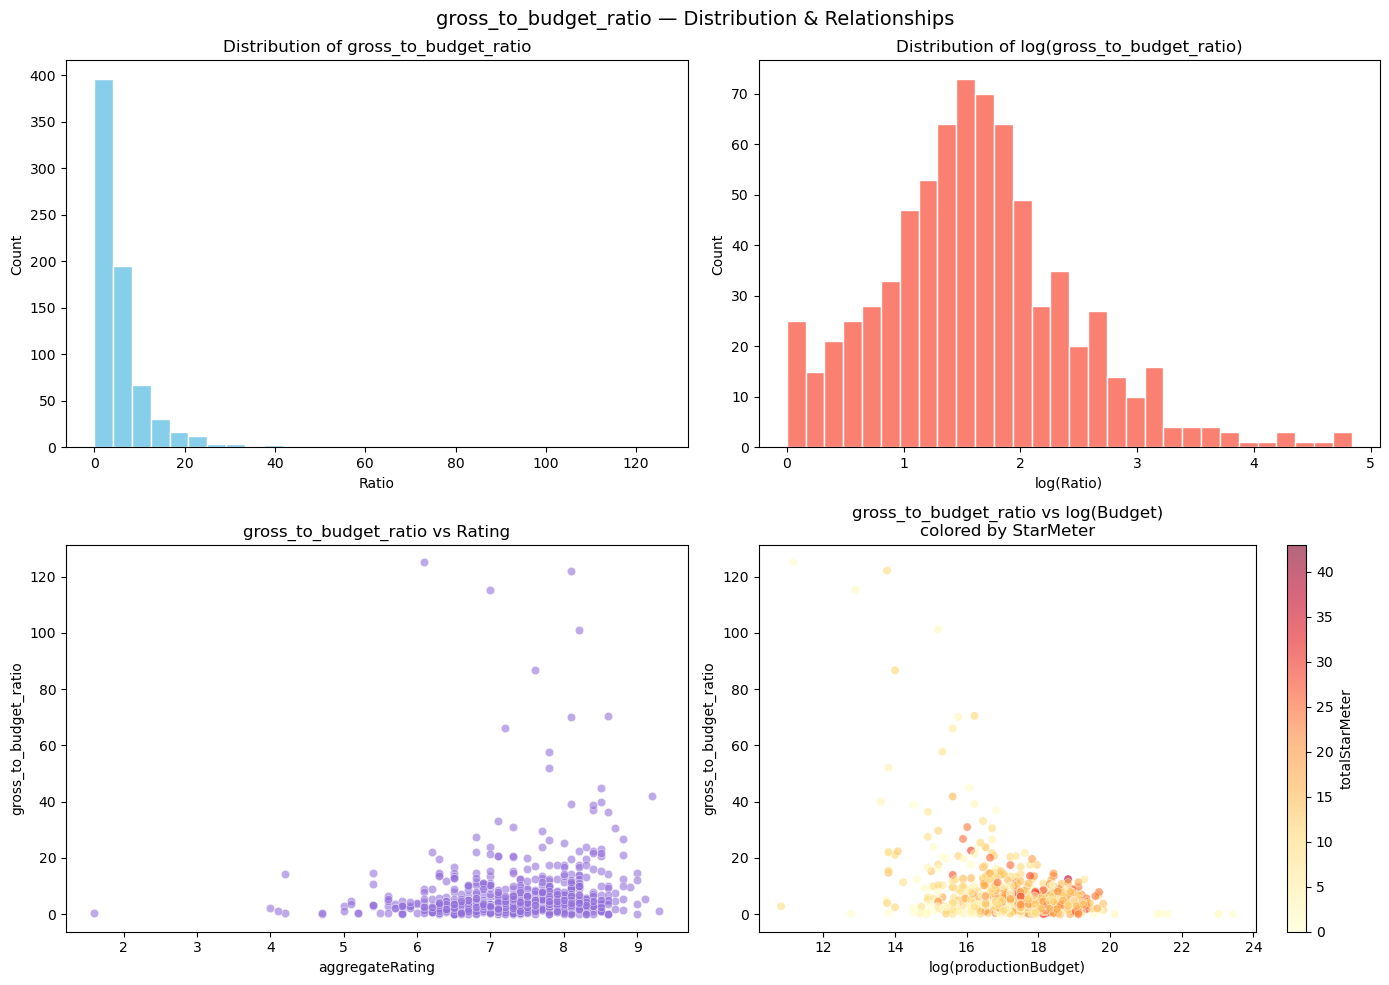

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# ── 1. Distribution of raw ratio ────────────────────────────────────
axes[0].hist(df["gross_to_budget_ratio"].dropna(), bins=30, color="skyblue", edgecolor="white")
axes[0].set_title("Distribution of gross_to_budget_ratio")
axes[0].set_xlabel("Ratio")
axes[0].set_ylabel("Count")

# ── 2. Log-transformed distribution ─────────────────────────────────
axes[1].hist(np.log1p(df["gross_to_budget_ratio"].dropna()), bins=30, color="salmon", edgecolor="white")
axes[1].set_title("Distribution of log(gross_to_budget_ratio)")
axes[1].set_xlabel("log(Ratio)")
axes[1].set_ylabel("Count")

# ── 3. Ratio vs aggregateRating ──────────────────────────────────────
axes[2].scatter(
    df["aggregateRating"], df["gross_to_budget_ratio"],
    alpha=0.6, color="mediumpurple", edgecolors="white", linewidths=0.4
)
axes[2].set_title("gross_to_budget_ratio vs Rating")
axes[2].set_xlabel("aggregateRating")
axes[2].set_ylabel("gross_to_budget_ratio")

# ── 4. Ratio vs productionBudget ─────────────────────────────────────
sc = axes[3].scatter(
    np.log1p(df["productionBudget"]), df["gross_to_budget_ratio"],
    c=df["totalStarMeter"], cmap="YlOrRd",
    alpha=0.6, edgecolors="white", linewidths=0.4
)
plt.colorbar(sc, ax=axes[3], label="totalStarMeter")
axes[3].set_title("gross_to_budget_ratio vs log(Budget)\ncolored by StarMeter")
axes[3].set_xlabel("log(productionBudget)")
axes[3].set_ylabel("gross_to_budget_ratio")

plt.suptitle("gross_to_budget_ratio — Distribution & Relationships", fontsize=14)
plt.tight_layout()
plt.show()